In [1]:
import numpy as np
from scipy.stats import norm

import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-colorblind')
plt.rcParams['lines.linewidth'] = 2.5
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['axes.labelsize'] = 14
plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12
plt.rcParams['legend.fontsize'] = 12
plt.rcParams['axes.edgecolor'] = 'black'
plt.rcParams['axes.linewidth'] = 1.2

# Prior predictive checks

In [2]:
mu = 150
sigma2 = 50**2

sigma2_noise = 20000**2

In [25]:
seed = 0
x = np.linspace(500, 2500, 10)  # square footage
noise = norm.rvs(0, 20000, size=10_000, random_state=seed)
prior_m_samples = norm.rvs(mu, np.sqrt(sigma2), size=10_000, random_state=seed)
prior_y_samples = prior_m_samples.reshape(-1, 1) * x.reshape(1, -1) + noise.reshape(-1, 1)
prior_y_samples.shape

(10000, 10)

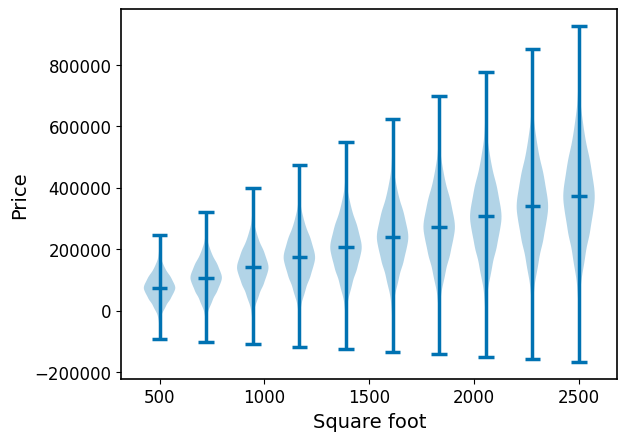

In [26]:
plt.violinplot(
    prior_y_samples, 
    positions=x, 
    widths=150,
    showmeans=True,
)
plt.xlabel("Square foot")
plt.ylabel("Price")
plt.show()

# Posterior predictive checks

In [27]:
np.random.seed(0)
x = np.linspace(500, 2500, 20)  # square footage
true_w = 200  # dollars per sqft
noise = np.random.normal(0, 20000, size=x.shape)
y = true_w * x + noise

In [28]:
post_sigma2 = 1 / (1 / sigma2 + (np.sum(x**2) / sigma2_noise))
post_mu = post_sigma2 * (mu / sigma2 + np.sum(x * y) / sigma2_noise)

In [29]:
noise = norm.rvs(0, 20000, size=10_000, random_state=seed + 1)
post_m_samples = norm.rvs(post_mu, np.sqrt(post_sigma2), size=10_000, random_state=seed)
post_y_samples = post_m_samples.reshape(-1, 1) * x.reshape(1, -1) + noise.reshape(-1, 1)

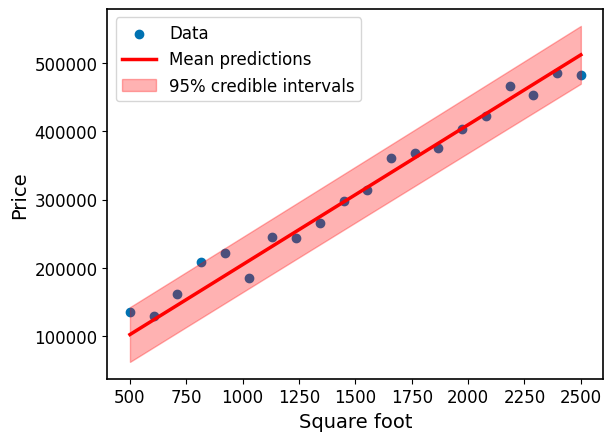

In [30]:
xs = np.linspace(500, 2500, 20)
y_mean = xs * post_mu
y_var = xs**2 * post_sigma2 + sigma2_noise
y_stddev = np.sqrt(y_var)

plt.scatter(x, y, label="Data")
plt.plot(xs, y_mean, c="r", label="Mean predictions")
plt.fill_between(
    xs,
    y_mean + 2 * y_stddev,
    y_mean - 2 * y_stddev,
    color="r",
    alpha=0.3,
    label="95% credible intervals"
)

plt.xlabel("Square foot")
plt.ylabel("Price")
plt.legend()

plt.show()

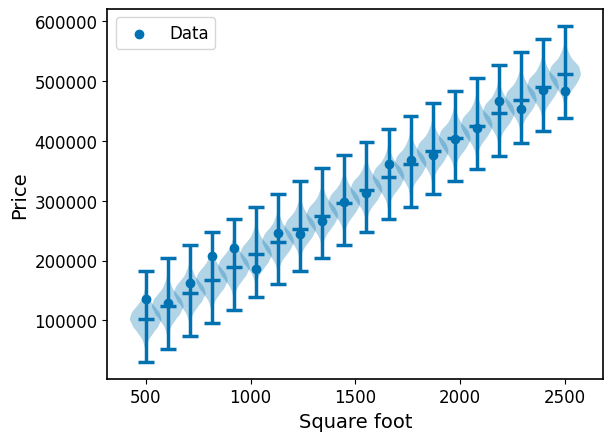

In [31]:
plt.scatter(x, y, label="Data")

plt.violinplot(
    post_y_samples, 
    positions=x, 
    widths=150,
    showmeans=True,
    # label="Posterior predictive samples",
)

plt.xlabel("Square foot")
plt.ylabel("Price")
plt.legend()

plt.show()